In [12]:
import pandas as pd
import seaborn as sns

In [42]:
df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [14]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [43]:
df = df.drop(columns=["embark_town","deck","alive","alone"])

In [44]:
df = df.drop(columns=['who','adult_male'])
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class
0,0,3,male,22.0,1,0,7.2500,S,Third
1,1,1,female,38.0,1,0,71.2833,C,First
2,1,3,female,26.0,0,0,7.9250,S,Third
3,1,1,female,35.0,1,0,53.1000,S,First
4,0,3,male,35.0,0,0,8.0500,S,Third
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second
887,1,1,female,19.0,0,0,30.0000,S,First
888,0,3,female,NaN,1,2,23.4500,S,Third
889,1,1,male,26.0,0,0,30.0000,C,First


In [45]:
df["sex"] = df["sex"].map({"male":0,"female":"1"})
df = pd.get_dummies(df,columns=["embarked"],drop_first=True)

In [46]:
df

,survived,pclass,sex,age,sibsp,parch,fare,class,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,Third,False,True
1,1,1,1,38.0,1,0,71.2833,First,False,False
2,1,3,1,26.0,0,0,7.9250,Third,False,True
3,1,1,1,35.0,1,0,53.1000,First,False,True
4,0,3,0,35.0,0,0,8.0500,Third,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,Second,False,True
887,1,1,1,19.0,0,0,30.0000,First,False,True
888,0,3,1,NaN,1,2,23.4500,Third,False,True
889,1,1,0,26.0,0,0,30.0000,First,False,False


In [47]:
df[['embarked_Q', 'embarked_S']] = df[['embarked_Q', 'embarked_S']].astype(int)

In [48]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
class,0
embarked_Q,0
embarked_S,0


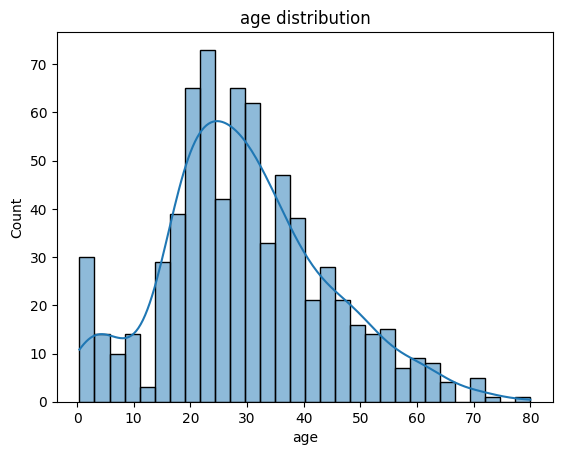

In [27]:
import matplotlib.pyplot as plt
sns.histplot(df['age'],kde=True,bins=30)
plt.title("age distribution")
plt.show()

In [28]:
df['age'].mean()

np.float64(29.69911764705882)

In [29]:
df['age'].median()

28.0

In [30]:
df['age'] = df['age'].fillna(df['age'].median())

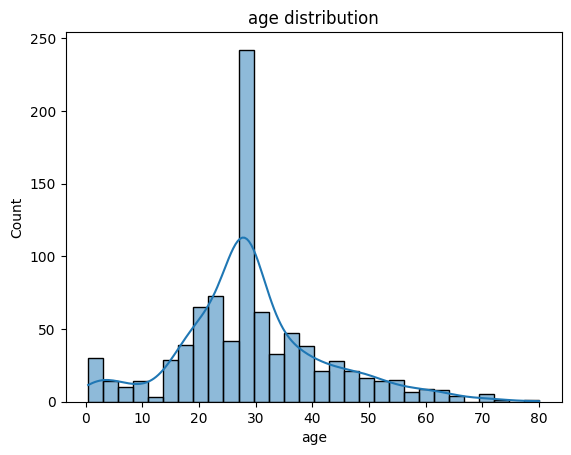

In [31]:

sns.histplot(df['age'],kde=True,bins=30)
plt.title("age distribution")
plt.show()

In [33]:
df

,survived,pclass,sex,age,sibsp,parch,fare,class,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,Third,0,1
1,1,1,1,38.0,1,0,71.2833,First,0,0
2,1,3,1,26.0,0,0,7.9250,Third,0,1
3,1,1,1,35.0,1,0,53.1000,First,0,1
4,0,3,0,35.0,0,0,8.0500,Third,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,Second,0,1
887,1,1,1,19.0,0,0,30.0000,First,0,1
888,0,3,1,28.0,1,2,23.4500,Third,0,1
889,1,1,0,26.0,0,0,30.0000,First,0,0


In [37]:
df['class'].unique()

['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']

In [49]:
df = df.drop(columns=['class'])
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1
...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0,1
887,1,1,1,19.0,0,0,30.0000,0,1
888,0,3,1,NaN,1,2,23.4500,0,1
889,1,1,0,26.0,0,0,30.0000,0,0


In [50]:
y = df['survived']
x = df.drop(columns=['survived'])



In [52]:
x

,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,3,0,22.0,1,0,7.2500,0,1
1,1,1,38.0,1,0,71.2833,0,0
2,3,1,26.0,0,0,7.9250,0,1
3,1,1,35.0,1,0,53.1000,0,1
4,3,0,35.0,0,0,8.0500,0,1
...,...,...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000,0,1
887,1,1,19.0,0,0,30.0000,0,1
888,3,1,NaN,1,2,23.4500,0,1
889,1,0,26.0,0,0,30.0000,0,0


In [55]:
df['family_size'] = df['sibsp'] + df['parch'] + 1

In [62]:
df = df.drop(columns=['sibsp','parch'])

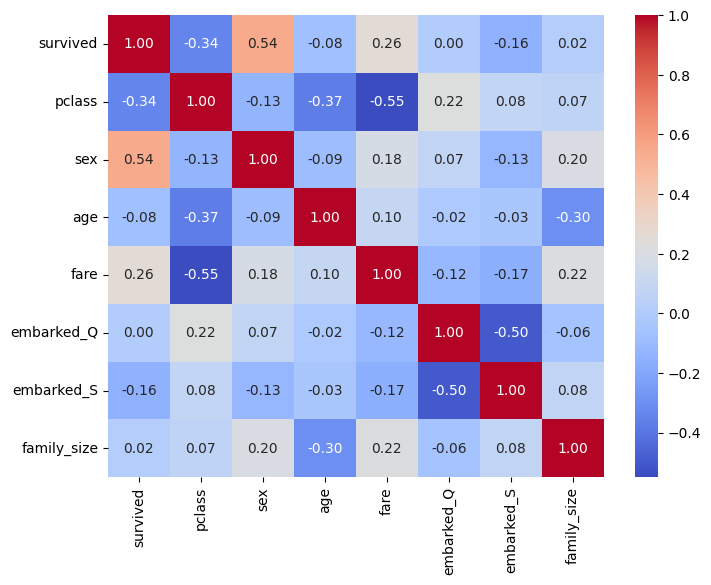

In [63]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.show()

In [60]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,family_size
0,0,3,0,22.0,1,0,7.2500,0,1,2
1,1,1,1,38.0,1,0,71.2833,0,0,2
2,1,3,1,26.0,0,0,7.9250,0,1,1
3,1,1,1,35.0,1,0,53.1000,0,1,2
4,0,3,0,35.0,0,0,8.0500,0,1,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0,1,1
887,1,1,1,19.0,0,0,30.0000,0,1,1
888,0,3,1,NaN,1,2,23.4500,0,1,4
889,1,1,0,26.0,0,0,30.0000,0,0,1


In [64]:
y = df['survived']
x = df.drop(columns=['survived'])



In [67]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [70]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [74]:
model = Sequential()
model.add(Dense(16,activation='relu',input_dim=x_train_scaled.shape[1]))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
history = model.fit(x_train_scaled,y_train,epochs=50,batch_size=16,validation_split=0.2,verbose=1)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6169 - loss: nan - val_accuracy: 0.6503 - val_loss: nan
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6169 - loss: nan - val_accuracy: 0.6503 - val_loss: nan
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6169 - loss: nan - val_accuracy: 0.6503 - val_loss: nan
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6169 - loss: nan - val_accuracy: 0.6503 - val_loss: nan
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6169 - loss: nan - val_accuracy: 0.6503 - val_loss: nan
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6169 - loss: nan - val_accuracy: 0.6503 - val_loss: nan
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6169 - loss: nan - val_accuracy: 0.6503 - val_loss: nan
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6169 - loss: nan - val_accuracy: 0.6503 - val_loss: nan
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━

In [79]:
y_pred = model.predict(x_test_scaled)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


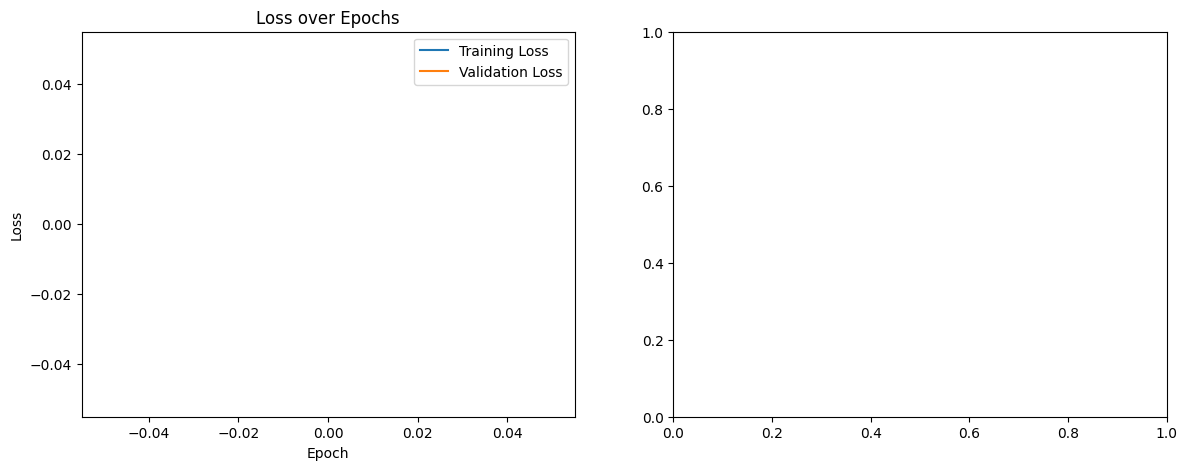

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

In [82]:
print(history.history['loss'][:5])
print(history.history['val_loss'][:5])

[nan, nan, nan, nan, nan]
[nan, nan, nan, nan, nan]


In [83]:
import numpy as np

# Check for NaNs in scaled training data
print("NaNs in X_train_scaled:", np.isnan(x_train_scaled).sum())







NaNs in X_train_scaled: 140


In [84]:
# Check for NaNs in target
print("NaNs in y_train:", y_train.isnull().sum())

NaNs in y_train: 0


In [85]:
# Check y_train only contains 0 and 1
print("Unique values in y_train:", y_train.unique())

Unique values in y_train: [0 1]


In [86]:
# Check for infinite values (can also cause NaN loss)
print("Infs in X_train_scaled:", np.isinf(x_train_scaled).sum())

Infs in X_train_scaled: 0


In [87]:
# 1. Confirm and fix the source dataframe
print(df.isnull().sum())
df['age'] = df['age'].fillna(df['age'].median())
print(df.isnull().sum())  # should be all zeros now

survived         0
pclass           0
sex              0
age            177
fare             0
embarked_Q       0
embarked_S       0
family_size      0
dtype: int64
survived       0
pclass         0
sex            0
age            0
fare           0
embarked_Q     0
embarked_S     0
family_size    0
dtype: int64


In [88]:
X = df.drop(columns=['survived'])
y = df['survived']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

# sanity check before moving on
print(np.isnan(x_train_scaled).sum())  # must be 0

0


In [89]:
model = Sequential()
model.add(Dense(16, activation='relu', input_dim=x_train_scaled.shape[1]))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train_scaled, y_train, validation_split=0.2, epochs=50, batch_size=16, verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5870 - loss: 0.6801 - val_accuracy: 0.6503 - val_loss: 0.6410
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6573 - loss: 0.6391 - val_accuracy: 0.6783 - val_loss: 0.6059
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6643 - loss: 0.6053 - val_accuracy: 0.6853 - val_loss: 0.5671
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6678 - loss: 0.5757 - val_accuracy: 0.6783 - val_loss: 0.5343
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6872 - loss: 0.5499 - val_accuracy: 0.7063 - val_loss: 0.5080
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7241 - loss: 0.5256 - val_accuracy: 0.7483 - val_loss: 0.4807
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7873 - loss: 0.4987 - val_accuracy: 0.7972 - val_loss: 0.4570
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7926 - loss: 0.4795 - val_accuracy: 0.8042 - val_loss: 0.4404


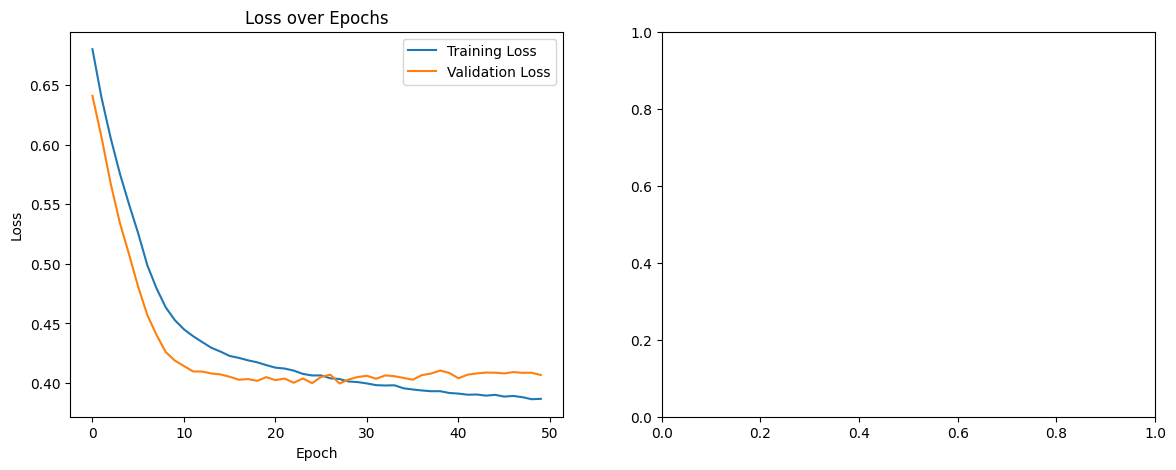

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

In [91]:
y_pred = model.predict(x_test_scaled)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [92]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_labels = (y_pred > 0.5).astype(int)

print("Test Accuracy (sklearn):", accuracy_score(y_test, y_pred_labels))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_labels))
print("\nClassification Report:\n", classification_report(y_test, y_pred_labels))

Test Accuracy (sklearn): 0.8156424581005587

Confusion Matrix:
 [[91 14]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179

